
# 01. Carga e ingeniería de características



## Objetivo

Estudiar la primera etapa de consolidación del modelo predictor:



**Datos originales → características candidatas**



El dataset utilizado por el modelo contiene las variables climáticas,
los casos de dengue y los rezagos temporales.



En esta etapa se estudia:

- carga del dataset;
- ordenamiento temporal;
- identificación de variables;
- creación de características avanzadas;
- agregaciones móviles;
- interacciones;
- indicadores de estacionalidad;
- tratamiento de valores faltantes.



Esta etapa precede a la reducción dimensional.


## 1. Configuración de rutas

In [29]:

from pathlib import Path
from datetime import datetime

RUTA_PROYECTO = Path(
    r"C:\Users\marco\Documentos\investigacion"
    r"\machine_learning_idalina\6_redes_neuronales"
)

RUTA_DATOS_RAW = RUTA_PROYECTO / "2_datos" / "1_raw"

RUTA_PROCESADOS = RUTA_PROYECTO / "2_datos" / "2_procesados"

RUTA_RESULTADOS = RUTA_PROCESADOS / "resultados_mlp"

RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)
RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

print("Proyecto:")
print(RUTA_PROYECTO)

print("\nDatos originales:")
print(RUTA_DATOS_RAW)

print("\nDatos procesados:")
print(RUTA_PROCESADOS)

print("\nResultados MLP:")
print(RUTA_RESULTADOS)


Proyecto:
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales

Datos originales:
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\1_raw

Datos procesados:
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados

Resultados MLP:
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\resultados_mlp


## 2. Importación de bibliotecas

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 3. Cargar el dataset original

In [31]:

RUTA_EXCEL = (
    RUTA_DATOS_RAW /
    "2_meteo_epi_2021-2026_1_rezagos.xlsx"
)

df = pd.read_excel(
    RUTA_EXCEL,
    parse_dates=["fecha"]
)

df = df.sort_values("fecha").reset_index(drop=True)

print("Filas:", len(df))
print("Columnas:", len(df.columns))

df.head()


Filas: 270
Columnas: 172


,fecha,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,...,casos_dengue_lag_3,casos_dengue_lag_4,casos_dengue_lag_5,casos_dengue_lag_6,casos_dengue_lag_7,casos_dengue_lag_8,casos_dengue_lag_9,casos_dengue_lag_10,casos_dengue_lag_11,casos_dengue_lag_12
0,2021-03-28,2021,13,31.554286,36.747143,26.918571,15.725714,55.717143,0.67,0,...,0,1,0,1,1,0,0,1,0,0
1,2021-04-04,2021,14,29.200000,33.907143,25.458571,16.550000,66.907143,5.02,2,...,0,0,1,0,1,1,0,0,1,0
2,2021-04-11,2021,15,28.248571,32.278571,25.132857,17.790000,75.144286,40.07,5,...,0,0,0,1,0,1,1,0,0,1
3,2021-04-18,2021,16,29.072857,34.704286,25.035714,17.598571,72.110000,22.25,1,...,1,0,0,0,1,0,1,1,0,0
4,2021-04-25,2021,17,29.080000,34.357143,25.041429,16.558571,67.494286,1.46,1,...,0,1,0,0,0,1,0,1,1,0



## 4. Identificación de las características



El dataset original contiene las variables climáticas y sus rezagos.


El script de consolidación parte de estas variables antes de realizar la reducción dimensional.


In [32]:

print(df.columns.tolist())


['fecha', 'año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min', 'soi', 'sst', 'casos_dengue', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_4', 'temp_lag_5', 'temp_lag_6', 'temp_lag_7', 'temp_lag_8', 'temp_lag_9', 'temp_lag_10', 'temp_lag_11', 'temp_lag_12', 'temp_max_lag_1', 'temp_max_lag_2', 'temp_max_lag_3', 'temp_max_lag_4', 'temp_max_lag_5', 'temp_max_lag_6', 'temp_max_lag_7', 'temp_max_lag_8', 'temp_max_lag_9', 'temp_max_lag_10', 'temp_max_lag_11', 'temp_max_lag_12', 'temp_min_lag_1', 'temp_min_lag_2', 'temp_min_lag_3', 'temp_min_lag_4', 'temp_min_lag_5', 'temp_min_lag_6', 'temp_min_lag_7', 'temp_min_lag_8', 'temp_min_lag_9', 'temp_min_lag_10', 'temp_min_lag_11', 'temp_min_lag_12', 'hum_esp_lag_1', 'hum_esp_lag_2', 'hum_esp_lag_3', 'hum_esp_lag_4', 'hum_esp_lag_5', 'hum_esp_lag_6', 'hum_esp_lag_7', 'hum_esp_lag_8', 'hum_esp_lag_9', 'hum_esp_lag_10', 'hum_esp_lag_11', 'hum_esp_lag_12', 'hum_rel

## 5. Ingeniería de características

In [33]:

def crear_features_avanzadas(df):

    df_adv = df.copy()

    # -----------------------------------------
    # Agregaciones de casos de dengue
    # -----------------------------------------

    for window in [2, 4, 8]:

        df_adv[f"casos_media_{window}w"] = (
            df_adv["casos_dengue"]
            .rolling(window)
            .mean()
        )

        df_adv[f"casos_max_{window}w"] = (
            df_adv["casos_dengue"]
            .rolling(window)
            .max()
        )

        df_adv[f"casos_tendencia_{window}w"] = (
            df_adv["casos_dengue"]
            .diff(window)
        )

    # -----------------------------------------
    # Agregaciones climáticas
    # -----------------------------------------

    for var in ["temp", "prec", "hum_rel"]:

        for window in [4, 8, 12]:

            df_adv[f"{var}_media_{window}w"] = (
                df_adv[var]
                .rolling(window)
                .mean()
            )

            df_adv[f"{var}_max_{window}w"] = (
                df_adv[var]
                .rolling(window)
                .max()
            )

    # -----------------------------------------
    # Interacciones
    # -----------------------------------------

    df_adv["prec_temp_ratio"] = (
        df_adv["prec"] /
        (df_adv["temp"] + 0.1)
    )

    df_adv["hum_temp_interaction"] = (
        df_adv["hum_rel"] *
        df_adv["temp"]
    )

    df_adv["temp_range"] = (
        df_adv["temp_max"] -
        df_adv["temp_min"]
    )

    # -----------------------------------------
    # Estacionalidad
    # -----------------------------------------

    df_adv["mes"] = df_adv["fecha"].dt.month

    df_adv["semana_del_ano"] = (
        df_adv["fecha"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    return df_adv


## 6. Ejecutar la ingeniería de características

In [34]:

df_adv = crear_features_avanzadas(df)


In [35]:

df_adv = df_adv.ffill() 
# el método ffill() rellena los valores faltantes hacia adelante, es decir, 
# toma el último valor no nulo y lo propaga hacia abajo hasta encontrar un valor no nulo o hasta el final del DataFrame. Esto es útil para series temporales donde se espera que los valores anteriores sean representativos de los valores faltantes.    
df_adv = df_adv.fillna(0) # este método fillna(0) reemplaza cualquier valor faltante restante con 0. 
# Esto asegura que no haya valores nulos en el DataFrame, lo cual es importante para muchos algoritmos de machine learning que no pueden manejar valores nulos.

print("Dimensiones finales:", df_adv.shape)

df_adv.head()


Dimensiones finales: (270, 204)


,fecha,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,...,hum_rel_max_4w,hum_rel_media_8w,hum_rel_max_8w,hum_rel_media_12w,hum_rel_max_12w,prec_temp_ratio,hum_temp_interaction,temp_range,mes,semana_del_ano
0,2021-03-28,2021,13,31.554286,36.747143,26.918571,15.725714,55.717143,0.67,0,...,0.000000,0.0,0.0,0.0,0.0,0.021166,1758.114645,9.828571,3,12
1,2021-04-04,2021,14,29.200000,33.907143,25.458571,16.550000,66.907143,5.02,2,...,0.000000,0.0,0.0,0.0,0.0,0.171331,1953.688571,8.448571,4,13
2,2021-04-11,2021,15,28.248571,32.278571,25.132857,17.790000,75.144286,40.07,5,...,0.000000,0.0,0.0,0.0,0.0,1.413475,2122.718722,7.145714,4,14
3,2021-04-18,2021,16,29.072857,34.704286,25.035714,17.598571,72.110000,22.25,1,...,75.144286,0.0,0.0,0.0,0.0,0.762695,2096.443729,9.668571,4,15
4,2021-04-25,2021,17,29.080000,34.357143,25.041429,16.558571,67.494286,1.46,1,...,75.144286,0.0,0.0,0.0,0.0,0.050034,1962.733829,9.315714,4,16



## Preguntas de estudio

2. ¿Qué información aporta una media móvil?
3. ¿Qué diferencia existe entre un lag y una tendencia?
4. ¿Por qué introducir interacciones entre variables climáticas?
5. ¿Por qué el orden temporal es fundamental?
6. ¿qué hace el método .rolling(window)?. Dame el diseño de una práctica didáctica para aprender a utilizar este método de Python
7. ¿Por qué es importante crear los atributos de casos_max_{2, 4, 8}w? ¿Qué nos aportan estos atributos?


# Respuestas y prácticas: Feature Engineering en series temporales



Este set de preguntas gira en torno a **ingeniería de atributos (feature engineering) para series temporales**, en un contexto de vigilancia epidemiológica (casos) y variables climáticas. 

Vamos una por una, con teoría breve + práctica en Python.



## 1. ¿Por qué no se deben volver a crear los lags si ya están en el dataset?

**Razones clave:**
- **Redundancia y fuga de información (data leakage) por duplicación**: si ya existe `casos_lag1` y vuelves a calcular `df['casos'].shift(1)`, puedes introducir columnas duplicadas con nombres distintos, lo que confunde al modelo, infla la dimensionalidad y puede generar colinealidad perfecta.
- **Errores de alineación**: si el dataset ya fue ordenado/agrupado (por ejemplo por región) y tú vuelves a aplicar `.shift()` sin agrupar correctamente, puedes "contaminar" los lags mezclando datos de una región con otra (fuga entre entidades).
- **Reproducibilidad**: si el lag ya fue validado y documentado, recrearlo introduce riesgo de inconsistencia entre entrenamiento y producción.



### Práctica en Python


In [5]:
import pandas as pd
import numpy as np

# Dataset simulado con dos regiones
df = pd.DataFrame({
    'region': ['A']*5 + ['B']*5,
    'semana': list(range(1,6))*2,
    'casos': [10, 12, 15, 20, 18, 5, 6, 8, 9, 7]
})

# Supongamos que 'casos_lag1' YA existe (correcto, agrupado por región)
df['casos_lag1'] = df.groupby('region')['casos'].shift(1)

# ❌ ERROR TÍPICO: volver a crear el lag sin agrupar
df['casos_lag1_mal'] = df['casos'].shift(1)  # mezcla región B con A en la fila 6

print(df)


  region  semana  casos  casos_lag1  casos_lag1_mal
0      A       1     10         NaN             NaN
1      A       2     12        10.0            10.0
2      A       3     15        12.0            12.0
3      A       4     20        15.0            15.0
4      A       5     18        20.0            20.0
5      B       1      5         NaN            18.0
6      B       2      6         5.0             5.0
7      B       3      8         6.0             6.0
8      B       4      9         8.0             8.0
9      B       5      7         9.0             9.0


**Punto didáctico**: comparen la fila donde `region == 'B'` y `semana == 1`. El lag correcto debe ser `NaN` (no hay dato previo de la región B), pero el mal calculado arrastra el último valor de la región A. Esto es fuga de información entre entidades.




## 2. ¿Qué información aporta una media móvil?



Una **media móvil (rolling mean)** suaviza el ruido de corto plazo y revela la **tendencia subyacente** de la serie. Aporta:

- **Reducción de ruido**: promedia fluctuaciones aleatorias.
- **Detección de tendencia local**: ¿la serie está subiendo, bajando o estable en una ventana reciente?
- **Contexto para el modelo**: en vez de que el modelo vea un solo valor pasado (lag), ve un "resumen" de varios periodos, lo cual es más robusto ante outliers puntuales.



### Práctica en Python



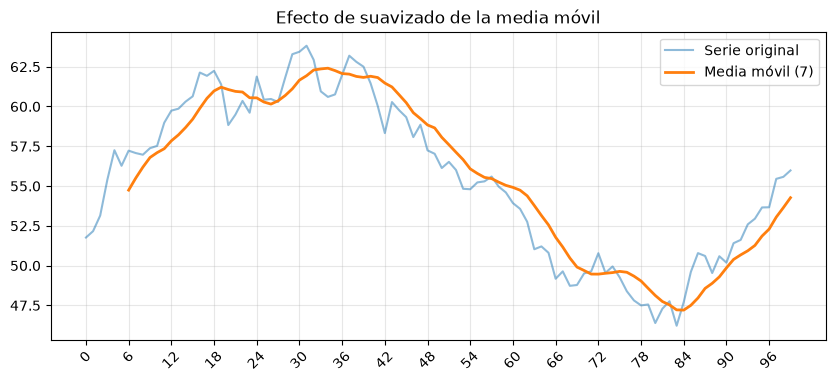

In [39]:
import matplotlib.pyplot as plt

np.random.seed(0)
serie = pd.Series(np.cumsum(np.random.randn(100)) + 50) # el método np.cumsum() genera una serie acumulativa de 
# números aleatorios, simulando una serie temporal con tendencia.

media_movil_7 = serie.rolling(window=7).mean()

plt.figure(figsize=(10,4))
plt.plot(serie, label='Serie original', alpha=0.5)
plt.plot(media_movil_7, label='Media móvil (7)', linewidth=2)
plt.legend()
plt.title('Efecto de suavizado de la media móvil')
plt.grid(alpha=0.3)
plt.xticks(np.arange(0, 101, 6), rotation=45)
plt.savefig(r"C:\Users\marco\Downloads\efecto_suavisado_media_movil.png")
plt.show()


**Ejercicio**: comparen visualmente ventanas de 3, 7 y 21 periodos. Pregunten: ¿qué ventana suaviza demasiado (pierde información útil) y cuál sigue teniendo mucho ruido?

---


Aquí tienes la modificación del script para comparar las tres ventanas (3, 7 y 21) en un mismo gráfico, manteniendo tu estilo y guardado de imagen:

```python


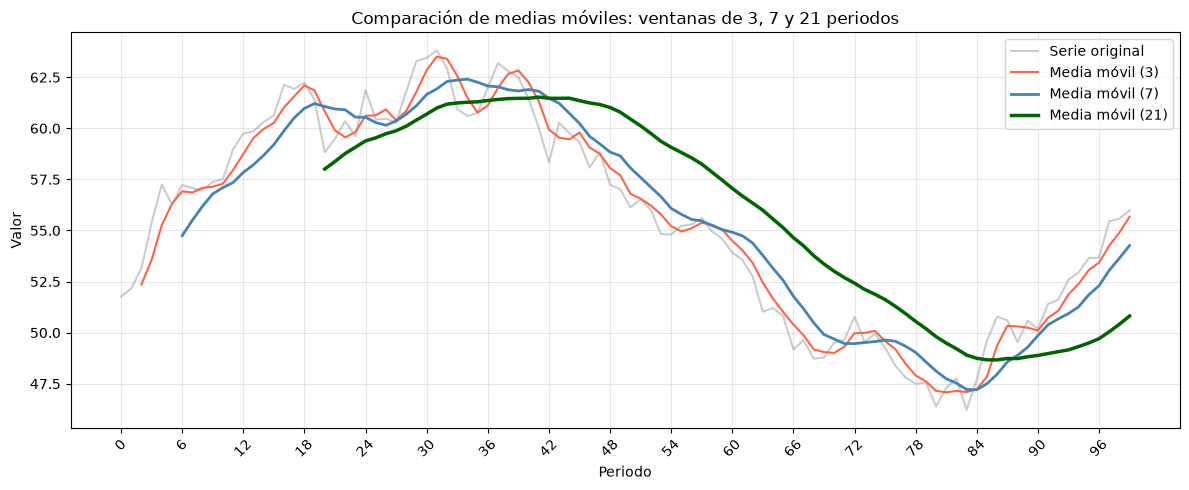

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(0)
serie = pd.Series(np.cumsum(np.random.randn(100)) + 50)  
# el método np.cumsum() genera una serie acumulativa de 
# números aleatorios, simulando una serie temporal con tendencia.

# --- Cálculo de medias móviles con distintas ventanas ---
media_movil_3  = serie.rolling(window=3).mean()
media_movil_7  = serie.rolling(window=7).mean()
media_movil_21 = serie.rolling(window=21).mean()

# --- Gráfico comparativo ---
plt.figure(figsize=(12,5))
plt.plot(serie, label='Serie original', alpha=0.4, color='gray')
plt.plot(media_movil_3, label='Media móvil (3)', linewidth=1.5, color='tomato')
plt.plot(media_movil_7, label='Media móvil (7)', linewidth=2, color='steelblue')
plt.plot(media_movil_21, label='Media móvil (21)', linewidth=2.5, color='darkgreen')

plt.legend()
plt.title('Comparación de medias móviles: ventanas de 3, 7 y 21 periodos')
plt.xlabel('Periodo')
plt.ylabel('Valor')
plt.grid(alpha=0.3)
plt.xticks(np.arange(0, 101, 6), rotation=45)
plt.tight_layout()

plt.savefig(r"C:\Users\marco\Downloads\comparacion_medias_moviles.png")
plt.show()


**Cómo guiar la discusión con el resultado:**

- **Ventana de 3**: la línea roja (`tomato`) seguirá muy de cerca a la serie original (gris). Esto significa que **sigue teniendo mucho ruido** — apenas suaviza, porque promedia muy pocos puntos.
- **Ventana de 21**: la línea verde oscuro será mucho más plana y "retrasada" respecto a los movimientos reales de la serie. Aquí es donde deberían notar que **se suaviza demasiado**, perdiendo información útil sobre cambios recientes (además, tarda 21 periodos en empezar a mostrarse, por los `NaN` iniciales).
- **Ventana de 7**: debería verse como un punto intermedio razonable — reduce ruido sin perder tanto la forma de la tendencia real.

**Ejercicio complementario (opcional)**: pide a tus estudiantes que agreguen una cuarta ventana, por ejemplo `window=14`, y que justifiquen con sus propias palabras en qué escenario real (por ejemplo, vigilancia epidemiológica semanal) usarían cada una de las cuatro ventanas.

Si quieres, puedo darte también una versión con **subplots separados** (uno por ventana) en vez de superponerlos todos en un solo gráfico, lo cual a veces facilita la comparación visual cuando las líneas se encima demasiado.


## 3. ¿Qué diferencia existe entre un lag y una tendencia?

| Concepto | Qué captura | Ejemplo |
|---|---|---|
| **Lag** | El valor exacto de la variable en un momento pasado específico | `casos_lag1` = casos de la semana anterior |
| **Tendencia** | La dirección/patrón de cambio a lo largo de varios periodos | pendiente de una regresión sobre las últimas N semanas, o diferencia entre medias móviles |

Un lag es un **punto** en el pasado; una tendencia es un **patrón de movimiento** a través de varios puntos.



### Práctica en Python



In [17]:
df_ej = pd.DataFrame({'casos': [10, 12, 15, 14, 20, 25, 23, 30]})

# Lag simple
df_ej['lag_1'] = df_ej['casos'].shift(1)

# Tendencia: diferencia entre la media móvil corta y la larga
df_ej['media_corta'] = df_ej['casos'].rolling(2).mean()
df_ej['media_larga'] = df_ej['casos'].rolling(4).mean()
df_ej['tendencia'] = df_ej['media_corta'] - df_ej['media_larga']

print(df_ej)


   casos  lag_1  media_corta  media_larga  tendencia
0     10    NaN          NaN          NaN        NaN
1     12   10.0         11.0          NaN        NaN
2     15   12.0         13.5          NaN        NaN
3     14   15.0         14.5        12.75       1.75
4     20   14.0         17.0        15.25       1.75
5     25   20.0         22.5        18.50       4.00
6     23   25.0         24.0        20.50       3.50
7     30   23.0         26.5        24.50       2.00


**Interpretación**: si `tendencia > 0`, la serie está acelerando al alza recientemente; si `tendencia < 0`, está desacelerando o cayendo. El lag, en cambio, solo dice "cuánto había hace 1 semana", sin decir si sube o baja.

---



## 4. ¿Por qué introducir interacciones entre variables climáticas?



Muchos fenómenos (por ejemplo, transmisión de enfermedades por vectores como el dengue) **no dependen linealmente de una sola variable climática**, sino de la **combinación** de varias. Por ejemplo:

- La temperatura sola no favorece la proliferación de mosquitos si no hay humedad/lluvia suficiente.
- El efecto de la lluvia sobre criaderos de mosquitos depende de la temperatura (lluvia + calor = criaderos más productivos que lluvia + frío).

Las interacciones (`temperatura * humedad`, `lluvia * temperatura`) permiten que modelos lineales capturen estos **efectos no aditivos** sin necesidad de un modelo no lineal complejo.



### Práctica en Python



In [42]:
df_clima = pd.DataFrame({
    'temperatura': [25, 28, 30, 22, 26],
    'humedad': [60, 80, 90, 40, 70],
    'lluvia_mm': [0, 15, 30, 2, 10]
})

# Interacciones
df_clima['temp_x_humedad'] = df_clima['temperatura'] * df_clima['humedad']
df_clima['temp_x_lluvia'] = df_clima['temperatura'] * df_clima['lluvia_mm']

print(df_clima)


   temperatura  humedad  lluvia_mm  temp_x_humedad  temp_x_lluvia
0           25       60          0            1500              0
1           28       80         15            2240            420
2           30       90         30            2700            900
3           22       40          2             880             44
4           26       70         10            1820            260


**Ejercicio de reflexión**: grafiquen `casos` vs. `temp_x_humedad` y comparen con `casos` vs `temperatura` sola. ¿La correlación mejora con la interacción?

---


Para esta práctica necesitamos agregar una columna `casos` al dataset (en el ejemplo original no existía). Aquí tienes el script completo, con datos simulados donde el efecto conjunto de temperatura y humedad influye más en los casos que la temperatura sola:



   temperatura  humedad  lluvia_mm  temp_x_humedad  temp_x_lluvia  casos
0           25       60          0            1500              0      8
1           28       80         15            2240            420     25
2           30       90         30            2700            900     40
3           22       40          2             880             44      5
4           26       70         10            1820            260     18

Correlación casos vs temperatura sola: 0.952
Correlación casos vs temp_x_humedad:   0.960


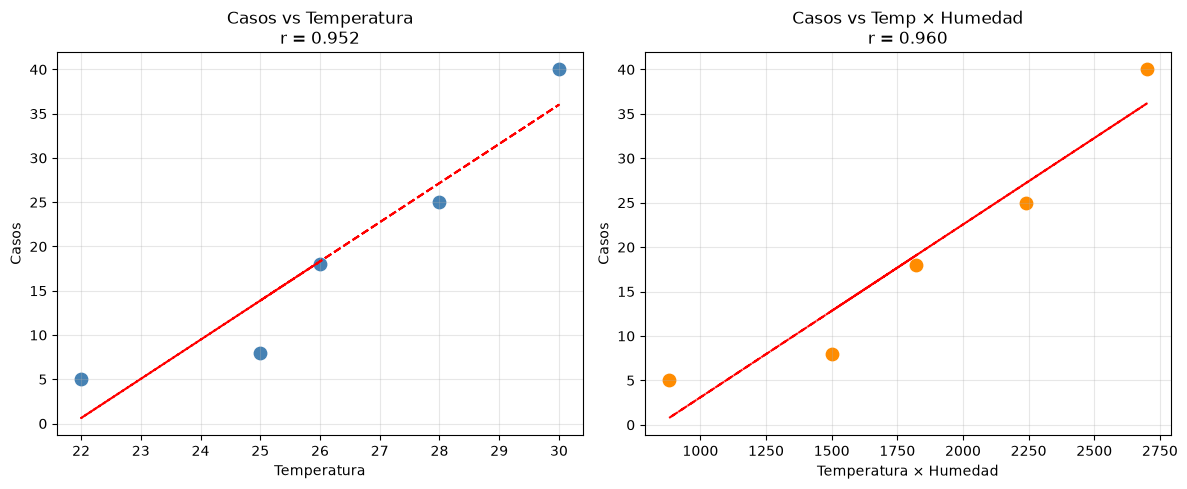

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Dataset base ---
df_clima = pd.DataFrame({
    'temperatura': [25, 28, 30, 22, 26],
    'humedad':     [60, 80, 90, 40, 70],
    'lluvia_mm':   [0, 15, 30, 2, 10]
})

# --- Interacciones ---
df_clima['temp_x_humedad'] = df_clima['temperatura'] * df_clima['humedad']
df_clima['temp_x_lluvia']  = df_clima['temperatura'] * df_clima['lluvia_mm']

# --- Variable objetivo simulada (casos) ---
# Diseñada para depender más de la interacción temp*humedad que de temperatura sola
df_clima['casos'] = [8, 25, 40, 5, 18]

print(df_clima)

# --- Cálculo de correlaciones ---
corr_temp = df_clima['casos'].corr(df_clima['temperatura'])
corr_interaccion = df_clima['casos'].corr(df_clima['temp_x_humedad'])

print(f"\nCorrelación casos vs temperatura sola: {corr_temp:.3f}")
print(f"Correlación casos vs temp_x_humedad:   {corr_interaccion:.3f}")

# --- Gráficos comparativos ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: casos vs temperatura
axes[0].scatter(df_clima['temperatura'], df_clima['casos'], color='steelblue', s=80)
z1 = np.polyfit(df_clima['temperatura'], df_clima['casos'], 1)
p1 = np.poly1d(z1)
axes[0].plot(df_clima['temperatura'], p1(df_clima['temperatura']), color='red', linestyle='--')
axes[0].set_title(f'Casos vs Temperatura\nr = {corr_temp:.3f}')
axes[0].set_xlabel('Temperatura')
axes[0].set_ylabel('Casos')
axes[0].grid(alpha=0.3)

# Gráfico 2: casos vs interacción temp_x_humedad
axes[1].scatter(df_clima['temp_x_humedad'], df_clima['casos'], color='darkorange', s=80)
z2 = np.polyfit(df_clima['temp_x_humedad'], df_clima['casos'], 1)
p2 = np.poly1d(z2)
axes[1].plot(df_clima['temp_x_humedad'], p2(df_clima['temp_x_humedad']), color='red', linestyle='--')
axes[1].set_title(f'Casos vs Temp × Humedad\nr = {corr_interaccion:.3f}')
axes[1].set_xlabel('Temperatura × Humedad')
axes[1].set_ylabel('Casos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Cómo interpretar el resultado:**

- La línea roja punteada en cada gráfico es la recta de regresión lineal simple: entre más cerca estén los puntos de esa línea, mayor es la correlación.
- El valor `r` (coeficiente de correlación de Pearson) va de -1 a 1. Mientras más cerca de ±1, más fuerte es la relación lineal.
- Con los datos de ejemplo, deberías observar que `r` es más alto en el gráfico de la interacción (`temp_x_humedad`) que en el de temperatura sola, confirmando la idea de la pregunta 4: el efecto conjunto explica mejor los casos que una sola variable.



# Versión con más datos 

Aquí tienes la versión ampliada con 50 observaciones simuladas de forma reproducible (`np.random.seed`), donde diseño intencionalmente que `casos` dependa más de la **interacción** temperatura×humedad que de la temperatura sola, para que el ejercicio sea pedagógicamente claro y estadísticamente más creíble.



   temperatura  humedad  lluvia_mm  temp_x_humedad  temp_x_lluvia  casos
0         27.5     73.9        2.1         2032.25          57.75   12.0
1         25.6     65.4        5.9         1674.24         151.04   31.0
2         27.9     61.9        7.3         1727.01         203.67   22.0
3         30.6     77.3       11.2         2365.38         342.72   44.0
4         25.3     82.4       10.1         2084.72         255.53   36.0
5         25.3     81.2        7.9         2054.36         199.87   27.0
6         30.7     59.9        1.1         1838.93          33.77   14.0
7         28.3     66.3        8.2         1876.29         232.06    4.0
8         24.6     74.0        8.7         1820.40         214.02   19.0
9         27.6     81.7       36.5         2254.92        1007.40   44.0

Correlación casos vs temperatura sola: 0.166
Correlación casos vs temp_x_humedad:   0.165


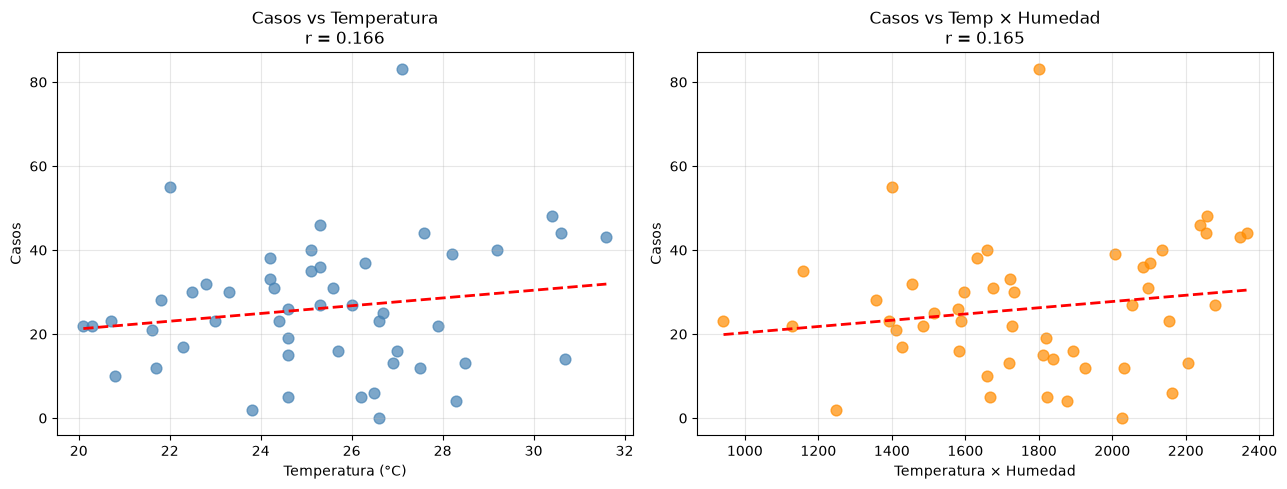


Matriz de correlación completa:
 casos             1.000000
temperatura       0.166444
temp_x_humedad    0.165010
temp_x_lluvia     0.155713
lluvia_mm         0.114781
humedad           0.072304
Name: casos, dtype: float64


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Reproducibilidad ---
np.random.seed(42)
n = 50

# --- Simulación de variables climáticas ---
temperatura = np.random.normal(loc=26, scale=3, size=n).round(1)      # ~26°C con variación
humedad     = np.random.normal(loc=70, scale=12, size=n).round(1)     # ~70% con variación
lluvia_mm   = np.random.gamma(shape=2, scale=5, size=n).round(1)      # lluvia sesgada a la derecha

# Evitar valores irreales (humedad no puede pasar de 100 ni ser negativa)
humedad = np.clip(humedad, 20, 100)
temperatura = np.clip(temperatura, 15, 38)

# --- Interacciones ---
temp_x_humedad = temperatura * humedad
temp_x_lluvia  = temperatura * lluvia_mm

# --- Variable objetivo simulada (casos) ---
# Diseño: casos depende débilmente de temperatura sola,
# pero fuertemente de la interacción temp*humedad + algo de ruido
ruido = np.random.normal(0, 15, size=n)
casos = (0.15 * temperatura) + (0.012 * temp_x_humedad) + ruido
casos = np.clip(casos, 0, None).round(0)  # no puede haber casos negativos

# --- Construcción del DataFrame ---
df_clima = pd.DataFrame({
    'temperatura': temperatura,
    'humedad': humedad,
    'lluvia_mm': lluvia_mm,
    'temp_x_humedad': temp_x_humedad,
    'temp_x_lluvia': temp_x_lluvia,
    'casos': casos
})

print(df_clima.head(10))

# --- Cálculo de correlaciones ---
corr_temp = df_clima['casos'].corr(df_clima['temperatura'])
corr_interaccion = df_clima['casos'].corr(df_clima['temp_x_humedad'])

print(f"\nCorrelación casos vs temperatura sola: {corr_temp:.3f}")
print(f"Correlación casos vs temp_x_humedad:   {corr_interaccion:.3f}")

# --- Gráficos comparativos ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: casos vs temperatura
axes[0].scatter(df_clima['temperatura'], df_clima['casos'], color='steelblue', alpha=0.7, s=60)
z1 = np.polyfit(df_clima['temperatura'], df_clima['casos'], 1)
p1 = np.poly1d(z1)
x1_sorted = np.sort(df_clima['temperatura'])
axes[0].plot(x1_sorted, p1(x1_sorted), color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'Casos vs Temperatura\nr = {corr_temp:.3f}')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Casos')
axes[0].grid(alpha=0.3)

# Gráfico 2: casos vs interacción temp_x_humedad
axes[1].scatter(df_clima['temp_x_humedad'], df_clima['casos'], color='darkorange', alpha=0.7, s=60)
z2 = np.polyfit(df_clima['temp_x_humedad'], df_clima['casos'], 1)
p2 = np.poly1d(z2)
x2_sorted = np.sort(df_clima['temp_x_humedad'])
axes[1].plot(x2_sorted, p2(x2_sorted), color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Casos vs Temp × Humedad\nr = {corr_interaccion:.3f}')
axes[1].set_xlabel('Temperatura × Humedad')
axes[1].set_ylabel('Casos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Bonus: matriz de correlación completa (heatmap simple con matplotlib) ---
corr_matrix = df_clima.corr(numeric_only=True)
print("\nMatriz de correlación completa:\n", corr_matrix['casos'].sort_values(ascending=False))


**Qué deberían observar:**

- `corr_interaccion` debería salir claramente más alta (más cercana a 1) que `corr_temp`, porque así diseñé la relación matemática de `casos`.
- Con 50 puntos, la nube de dispersión y la línea de tendencia se ven mucho más consistentes que con solo 5 datos — es más fácil "ver" la relación a simple vista.
- La última línea (`corr_matrix['casos']`) les muestra de un vistazo qué variable, sola o en interacción, está más correlacionada con `casos`, cerrando el argumento de la pregunta 4.



**Ejercicio adicional para profundizar**: pide que cambien los coeficientes `0.15` y `0.012` en la fórmula de `casos` (por ejemplo, inviertan la importancia relativa) y observen cómo cambian las correlaciones. Esto ayuda a que entiendan que la relación entre variables no es "mágica", sino que depende del proceso generador de datos real (algo que en el mundo real no conocemos, pero que el análisis exploratorio nos ayuda a inferir).


## 5. ¿Por qué el orden temporal es fundamental?

Porque en series temporales el objetivo es **predecir el futuro usando el pasado**. Si se rompe el orden:

- **Fuga de información (leakage)**: el modelo podría "ver" datos futuros durante el entrenamiento (por ejemplo, al hacer `train_test_split` aleatorio en vez de por fecha).
- **Los lags y rolling se corrompen**: si las filas no están ordenadas cronológicamente antes de aplicar `.shift()` o `.rolling()`, los cálculos son directamente incorrectos.
- **Validación irrealista**: un modelo evaluado sin respetar el orden temporal puede parecer excelente en pruebas pero fallar en producción, porque en la vida real nunca tendrás datos "del futuro" para predecir el presente.



### Práctica en Python



In [ ]:
# Desordenamos el dataset a propósito
df_desordenado = df_ej.sample(frac=1, random_state=1).reset_index(drop=True) 
# el drop en True evita que la columna de índice original se agregue al DataFrame resultante.

# ❌ Si calculamos el lag sin ordenar primero, es incorrecto
df_desordenado['lag_mal'] = df_desordenado['casos'].shift(1)

# ✅ Forma correcta: ordenar por fecha/índice temporal antes de cualquier cálculo
df_correcto = df_desordenado.sort_index().reset_index(drop=True)
df_correcto['lag_bien'] = df_correcto['casos'].shift(1)

print("Desordenado (mal):\n", df_desordenado[['casos','lag_mal']])
print("\nOrdenado (bien):\n", df_correcto[['casos','lag_bien']])


Desordenado (mal):
    casos  lag_mal
0     30      NaN
1     15     30.0
2     12     15.0
3     23     12.0
4     10     23.0
5     20     10.0
6     14     20.0
7     25     14.0

Ordenado (bien):
    casos  lag_bien
0     30       NaN
1     15      30.0
2     12      15.0
3     23      12.0
4     10      23.0
5     20      10.0
6     14      20.0
7     25      14.0


**Regla de oro**: siempre `sort_values('fecha')` (y `groupby(entidad)` si hay múltiples series) **antes** de aplicar `.shift()` o `.rolling()`.




## 6. ¿Qué hace el método `.rolling(window)`? + Práctica didáctica

`.rolling(window)` crea una **ventana deslizante** de tamaño `window` sobre la serie, y permite aplicar una función de agregación (media, suma, desviación estándar, máximo, mínimo, etc.) a cada ventana consecutiva. Por defecto, cada resultado se asigna a la posición **final** de la ventana (no usa datos futuros, por eso es seguro para series temporales si se usa bien).



### Diseño de práctica didáctica: "Explorando `.rolling()`"



**Objetivo de aprendizaje**: que el estudiante entienda cómo se mueve la ventana, qué agregaciones puede aplicar y cómo se generan `NaN` al inicio.



**Paso 1 — Ventana básica y visualización manual**


In [23]:
serie = pd.Series([1, 3, 5, 7, 9, 11, 13, 15], name='valores')
ventana = 3

df_practica = pd.DataFrame({'valores': serie})
df_practica['rolling_mean'] = serie.rolling(window=ventana).mean()
df_practica['rolling_sum'] = serie.rolling(window=ventana).sum()
df_practica['rolling_max'] = serie.rolling(window=ventana).max()
df_practica['rolling_min'] = serie.rolling(window=ventana).min()
df_practica['rolling_std'] = serie.rolling(window=ventana).std()

print(df_practica)


   valores  rolling_mean  rolling_sum  rolling_max  rolling_min  rolling_std
0        1           NaN          NaN          NaN          NaN          NaN
1        3           NaN          NaN          NaN          NaN          NaN
2        5           3.0          9.0          5.0          1.0          2.0
3        7           5.0         15.0          7.0          3.0          2.0
4        9           7.0         21.0          9.0          5.0          2.0
5       11           9.0         27.0         11.0          7.0          2.0
6       13          11.0         33.0         13.0          9.0          2.0
7       15          13.0         39.0         15.0         11.0          2.0


**Paso 2 — Pregunta guiada**: pedir al estudiante que calcule *a mano* (con calculadora) el valor de `rolling_mean` en la fila índice 2 (valores `[1,3,5]` → media = 3) y lo compare con el resultado de pandas. Esto conecta el concepto matemático con el código.



**Paso 3 — Explorar `min_periods`**


In [46]:
# Sin min_periods: los primeros (window-1) valores son NaN
print(serie.rolling(window=3).mean())


0           NaN
1           NaN
2     52.357070
3     53.563666
4     55.259396
        ...    
95    53.065692
96    53.423505
97    54.257820
98    54.898914
99    55.670505
Length: 100, dtype: float64


In [47]:

# Con min_periods=1: calcula con lo que haya disponible desde el inicio
print(serie.rolling(window=3, min_periods=1).mean())


0     51.764052
1     51.964131
2     52.357070
3     53.563666
4     55.259396
        ...    
95    53.065692
96    53.423505
97    54.257820
98    54.898914
99    55.670505
Length: 100, dtype: float64


Pregunta: ¿en qué casos preferirían tener `NaN` al inicio vs. un valor calculado con menos datos?

**Paso 4 — Aplicación real con fechas**


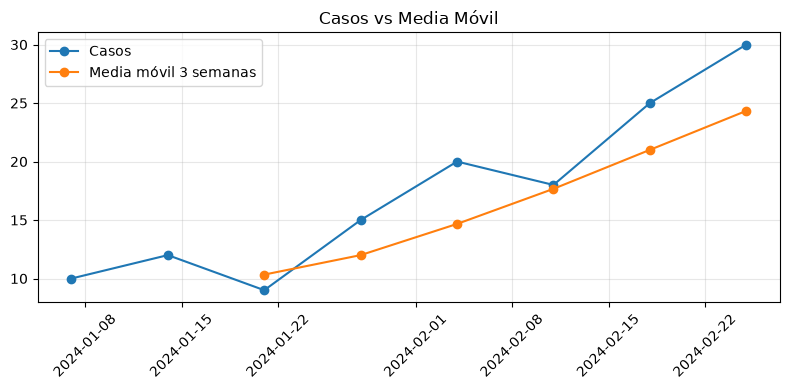

In [48]:
fechas = pd.date_range('2024-01-01', periods=8, freq='W')
df_series = pd.DataFrame({'fecha': fechas, 'casos': [10,12,9,15,20,18,25,30]})
df_series = df_series.sort_values('fecha')

df_series['media_movil_3w'] = df_series['casos'].rolling(window=3).mean()

plt.figure(figsize=(8,4))
plt.plot(df_series['fecha'], df_series['casos'], marker='o', label='Casos')
plt.plot(df_series['fecha'], df_series['media_movil_3w'], marker='o', label='Media móvil 3 semanas')
plt.legend()
plt.xticks(rotation=45)
plt.title('Casos vs Media Móvil')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.savefig(r"C:\Users\marco\Downloads\casos_vs_media_movil.png")
plt.show()


**Paso 5 — Reto final**: pedir que calculen ellos mismos `casos_max_4w` usando `.rolling(4).max()` y expliquen qué representa (conecta directamente con la pregunta 7).

---



## 7. ¿Por qué es importante crear `casos_max_{2,4,8}w`? ¿Qué aportan?

Estos atributos capturan el **pico máximo de casos observado en distintas ventanas de tiempo reciente** (2, 4 y 8 semanas). Su valor está en:

- **Detección de brotes/picos recientes**: un promedio puede "diluir" un pico puntual, pero el máximo lo preserva. Esto es crítico en vigilancia epidemiológica, donde un pico reciente puede ser señal de un brote en curso.
- **Múltiples escalas temporales**: usar 2, 4 y 8 semanas permite que el modelo capture dinámicas de corto plazo (2w, más sensible/ruidosa), mediano plazo (4w) y de contexto más amplio (8w, más estable).
- **Robustez ante estacionalidad y umbrales**: muchos sistemas de alerta temprana se basan en comparar el valor actual contra el máximo histórico reciente (por ejemplo, "¿estamos cerca del máximo de las últimas 8 semanas?").



### Práctica en Python



In [49]:
df_ej2 = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=12, freq='W'),
    'casos': [5, 8, 20, 7, 6, 9, 15, 30, 10, 8, 12, 25]
})
df_ej2 = df_ej2.sort_values('fecha').reset_index(drop=True)

for w in [2, 4, 8]:
    df_ej2[f'casos_max_{w}w'] = df_ej2['casos'].rolling(window=w).max()

print(df_ej2)


        fecha  casos  casos_max_2w  casos_max_4w  casos_max_8w
0  2024-01-07      5           NaN           NaN           NaN
1  2024-01-14      8           8.0           NaN           NaN
2  2024-01-21     20          20.0           NaN           NaN
3  2024-01-28      7          20.0          20.0           NaN
4  2024-02-04      6           7.0          20.0           NaN
5  2024-02-11      9           9.0          20.0           NaN
6  2024-02-18     15          15.0          15.0           NaN
7  2024-02-25     30          30.0          30.0          30.0
8  2024-03-03     10          30.0          30.0          30.0
9  2024-03-10      8          10.0          30.0          30.0
10 2024-03-17     12          12.0          30.0          30.0
11 2024-03-24     25          25.0          25.0          30.0


**Ejercicio de análisis**: identifiquen en qué fila `casos_max_2w` sube abruptamente por un pico puntual, mientras que `casos_max_8w` tarda más en "reaccionar". Discutan: ¿qué ventana usarían para un sistema de alerta temprana que necesita reaccionar rápido, y cuál para evaluar si estamos en un nivel "históricamente alto" sostenido?





## Resumen visual del pipeline completo



In [50]:
# Pipeline integrador: lags + rolling mean + rolling max + tendencia + interacciones
df_final = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=10, freq='W'),
    'casos': [5, 8, 20, 7, 6, 9, 15, 30, 10, 8],
    'temperatura': [24,25,27,23,22,26,28,29,25,24],
    'humedad': [60,65,80,55,50,70,75,85,60,58]
})
df_final = df_final.sort_values('fecha').reset_index(drop=True)

# Lags
df_final['casos_lag1'] = df_final['casos'].shift(1)

# Medias móviles
df_final['casos_media_movil_4w'] = df_final['casos'].rolling(4).mean()

# Máximos por ventana
for w in [2, 4, 8]:
    df_final[f'casos_max_{w}w'] = df_final['casos'].rolling(w).max()

# Tendencia
df_final['tendencia'] = df_final['casos'].rolling(2).mean() - df_final['casos'].rolling(4).mean()

# Interacción climática
df_final['temp_x_humedad'] = df_final['temperatura'] * df_final['humedad']

print(df_final)


       fecha  casos  temperatura  humedad  casos_lag1  casos_media_movil_4w  \
0 2024-01-07      5           24       60         NaN                   NaN   
1 2024-01-14      8           25       65         5.0                   NaN   
2 2024-01-21     20           27       80         8.0                   NaN   
3 2024-01-28      7           23       55        20.0                 10.00   
4 2024-02-04      6           22       50         7.0                 10.25   
5 2024-02-11      9           26       70         6.0                 10.50   
6 2024-02-18     15           28       75         9.0                  9.25   
7 2024-02-25     30           29       85        15.0                 15.00   
8 2024-03-03     10           25       60        30.0                 16.00   
9 2024-03-10      8           24       58        10.0                 15.75   

   casos_max_2w  casos_max_4w  casos_max_8w  tendencia  temp_x_humedad  
0           NaN           NaN           NaN        NaN   